# EDA: Premier League Player Transfer Value

Distribution of market value, market value vs. age, missingness, and correlation of value against performance stats.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_loader import build_dataset

sns.set_theme(style="whitegrid")

df = build_dataset()

# Fixed approximate EUR->USD rate for readability; not FX-adjusted per season.
USD_PER_EUR = 1.08
df["market_value_usd_m"] = df["market_value_eur"] * USD_PER_EUR / 1_000_000

df.shape

(6295, 18)

In [2]:
df.head()

,player_id,season,market_value_eur,goals,assists,minutes_played,num_appearances,yellow_cards,red_cards,name,date_of_birth,position,sub_position,foot,height_in_cm,country_of_citizenship,age,market_value_usd_m
0,132,2012,2000000,2,1,612,10,2,0,Tomas Rosicky,1980-10-04,Midfield,Attacking Midfield,both,179.0,Czech Republic,32.0,2.16
1,132,2013,2000000,2,1,1572,27,7,0,Tomas Rosicky,1980-10-04,Midfield,Attacking Midfield,both,179.0,Czech Republic,33.0,2.16
2,132,2014,2000000,2,1,576,15,1,0,Tomas Rosicky,1980-10-04,Midfield,Attacking Midfield,both,179.0,Czech Republic,34.0,2.16
3,488,2012,750000,0,0,1109,14,0,0,Gerhard Tremmel,1978-11-16,Goalkeeper,Goalkeeper,NaN,NaN,Germany,34.0,0.81
4,488,2013,1000000,0,0,1080,12,0,0,Gerhard Tremmel,1978-11-16,Goalkeeper,Goalkeeper,NaN,NaN,Germany,35.0,1.08


# EDA: Premier League Player Transfer Value

Distribution of market value (USD millions), market value vs. age, missingness, correlation of value against performance stats, and which player characteristics add or subtract the most value.

All monetary figures below are in **millions of USD** (`market_value_usd_m`), converted from the source EUR values at a fixed rate of 1.08 USD/EUR for readability.

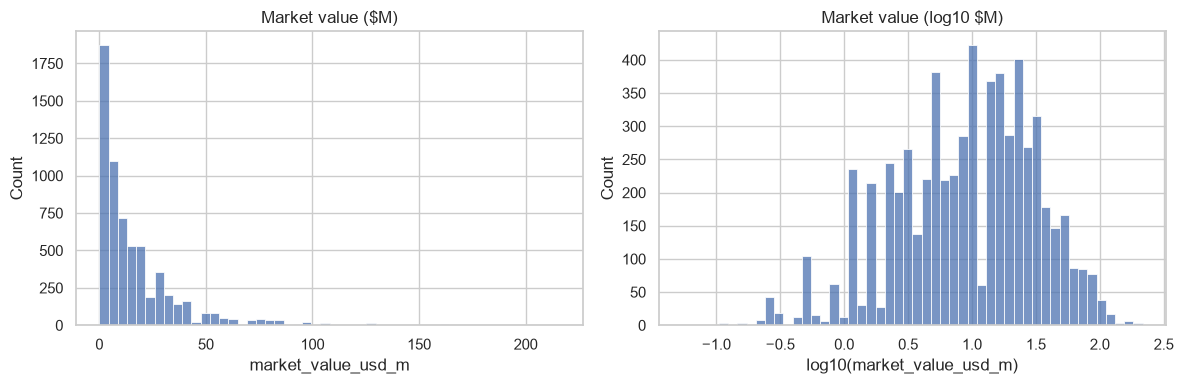

count    6295.000000
mean       17.233699
std        20.583229
min         0.054000
25%         3.780000
50%        10.800000
75%        21.600000
max       216.000000
Name: market_value_usd_m, dtype: float64

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["market_value_usd_m"], bins=50, ax=axes[0])
axes[0].set_title("Market value ($M)")
axes[0].set_xlabel("market_value_usd_m")

sns.histplot(np.log10(df["market_value_usd_m"].replace(0, np.nan).dropna()), bins=50, ax=axes[1])
axes[1].set_title("Market value (log10 $M)")
axes[1].set_xlabel("log10(market_value_usd_m)")

plt.tight_layout()
plt.show()

df["market_value_usd_m"].describe()

Market value is heavily right-skewed (a small number of high-value stars pull the raw distribution far to the right); the log scale looks close to log-normal, which is the usual reason to model `log(market_value_usd_m)` rather than the raw value.

## Market value vs. age

Expecting a non-linear relationship: value rising through a player's early 20s, peaking roughly around 24-27, then declining — not a straight line.

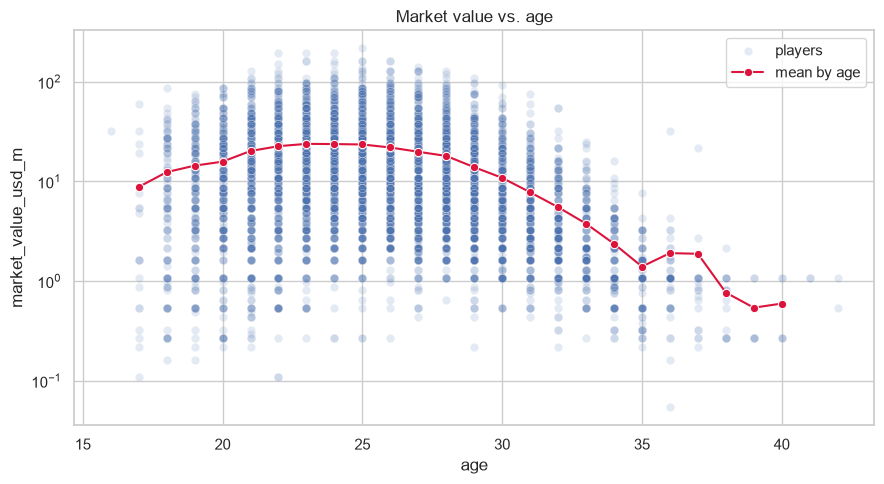

,age,mean,median,count
7,23.0,23.797188,16.20,485
8,24.0,23.688142,16.20,508
9,25.0,23.459905,16.20,567
6,22.0,22.553020,16.20,404
10,26.0,21.880551,16.20,563
5,21.0,20.187698,12.96,348
11,27.0,19.820250,12.96,552
12,28.0,17.999168,12.96,519
4,20.0,15.778760,10.80,271
3,19.0,14.380894,8.64,179


In [4]:
age_value = df.dropna(subset=["age", "market_value_usd_m"])
age_stats = age_value.groupby("age")["market_value_usd_m"].agg(["mean", "median", "count"]).reset_index()
age_stats = age_stats[age_stats["count"] >= 5]

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=age_value, x="age", y="market_value_usd_m", alpha=0.15, ax=ax, label="players")
sns.lineplot(data=age_stats, x="age", y="mean", color="crimson", marker="o", ax=ax, label="mean by age")
ax.set_yscale("log")
ax.set_ylabel("market_value_usd_m")
ax.set_title("Market value vs. age")
plt.tight_layout()
plt.show()

age_stats.sort_values("mean", ascending=False).head(10)

## Missingness report

In [5]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
}).sort_values("pct_missing", ascending=False)
missing

,n_missing,pct_missing
foot,35,0.56
height_in_cm,20,0.32
country_of_citizenship,18,0.29
age,4,0.06
date_of_birth,4,0.06
player_id,0,0.00
season,0,0.00
sub_position,0,0.00
position,0,0.00
name,0,0.00


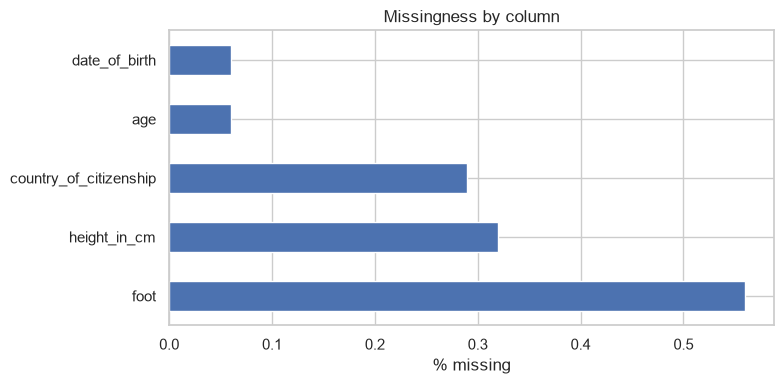

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
missing[missing["pct_missing"] > 0]["pct_missing"].plot.barh(ax=ax)
ax.set_xlabel("% missing")
ax.set_title("Missingness by column")
plt.tight_layout()
plt.show()

## Correlation of value against performance stats

Raw `goals`/`assists` totals are confounded with playing time — a player who's on the
pitch more will rack up more of both regardless of quality, so those correlations
partly just measure "how much did this player play." Converting to **per-90-minutes
rates** removes that confound. We also correlate against `log10(market_value_usd_m)`
rather than the raw value, since the distribution above is heavily right-skewed and
log makes the relationship closer to linear (and less dominated by a few outlier
transfers).

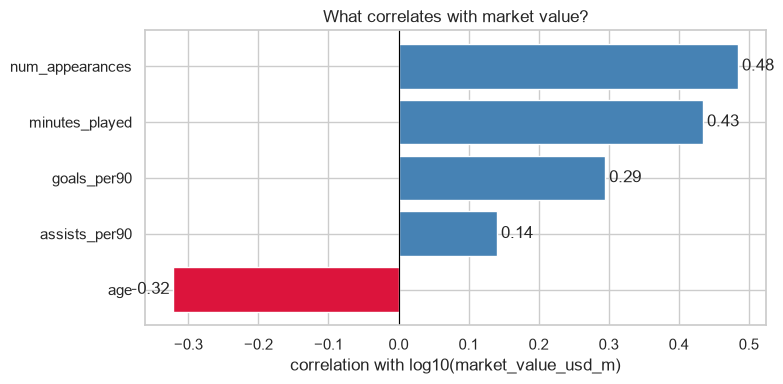

num_appearances    0.484326
minutes_played     0.434401
goals_per90        0.294666
assists_per90      0.140308
age               -0.321355
Name: log_market_value_usd_m, dtype: float64

In [7]:
nineties = df["minutes_played"] / 90
df["goals_per90"] = np.where(nineties > 0, df["goals"] / nineties, np.nan)
df["assists_per90"] = np.where(nineties > 0, df["assists"] / nineties, np.nan)
df["log_market_value_usd_m"] = np.log10(df["market_value_usd_m"])

feature_cols = ["goals_per90", "assists_per90", "minutes_played", "num_appearances", "age"]
corr = df[feature_cols + ["log_market_value_usd_m"]].corr()["log_market_value_usd_m"].drop("log_market_value_usd_m")
corr = corr.sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["crimson" if v < 0 else "steelblue" for v in corr]
bars = ax.barh(corr.index, corr.values, color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_xlabel("correlation with log10(market_value_usd_m)")
ax.set_title("What correlates with market value?")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

corr.sort_values(ascending=False)

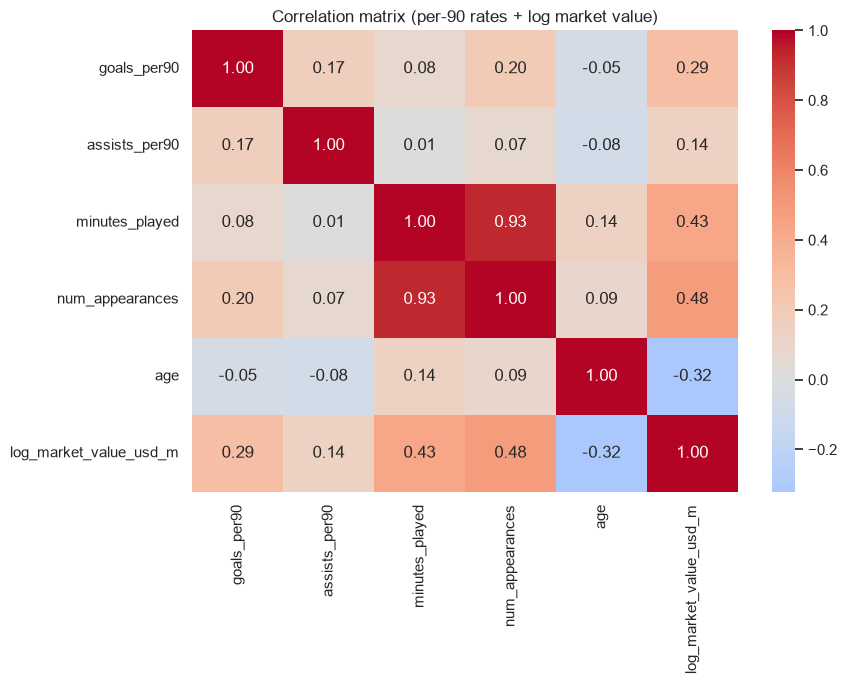

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    df[feature_cols + ["log_market_value_usd_m"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
)
ax.set_title("Correlation matrix (per-90 rates + log market value)")
plt.tight_layout()
plt.show()

## Which player characteristics add or subtract the most value?

For each characteristic (sub-position, position, preferred foot), we compare the
average market value of players in that category against the overall average. A
category with a large positive deviation is associated with higher-than-typical
value; a large negative deviation, lower. Categories with fewer than 15
player-seasons are dropped so the comparison isn't driven by noise.

In [9]:
def value_deviation(data: pd.DataFrame, group_col: str, value_col: str = "market_value_usd_m", min_count: int = 15) -> pd.DataFrame:
    """Mean value per category vs. the overall mean, for categories with enough samples."""
    stats = data.groupby(group_col)[value_col].agg(["mean", "count"])
    stats = stats[stats["count"] >= min_count]
    stats["deviation_usd_m"] = stats["mean"] - data[value_col].mean()
    return stats.sort_values("deviation_usd_m")


def plot_deviation(stats: pd.DataFrame, title: str, ax: plt.Axes | None = None, top_n: int | None = None) -> plt.Axes:
    if top_n is not None:
        stats = pd.concat([stats.head(top_n), stats.tail(top_n)])
    if ax is None:
        _, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(stats))))
    colors = ["crimson" if v < 0 else "steelblue" for v in stats["deviation_usd_m"]]
    bars = ax.barh(stats.index, stats["deviation_usd_m"], color=colors)
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("deviation from overall mean value ($M)")
    ax.set_title(title)
    return ax


sub_position_dev = value_deviation(df, "sub_position")
position_dev = value_deviation(df, "position")
foot_dev = value_deviation(df, "foot")

### By sub-position (the biggest gainers and losers)

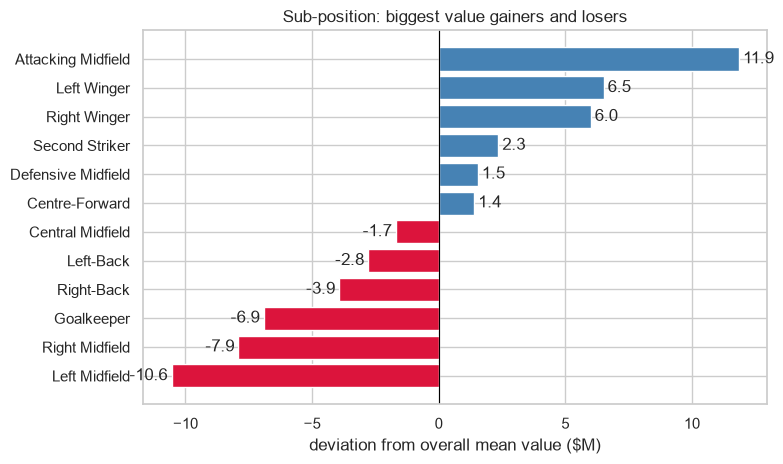

In [10]:
plot_deviation(sub_position_dev, "Sub-position: biggest value gainers and losers", top_n=6)
plt.tight_layout()
plt.show()

### By broad position and preferred foot

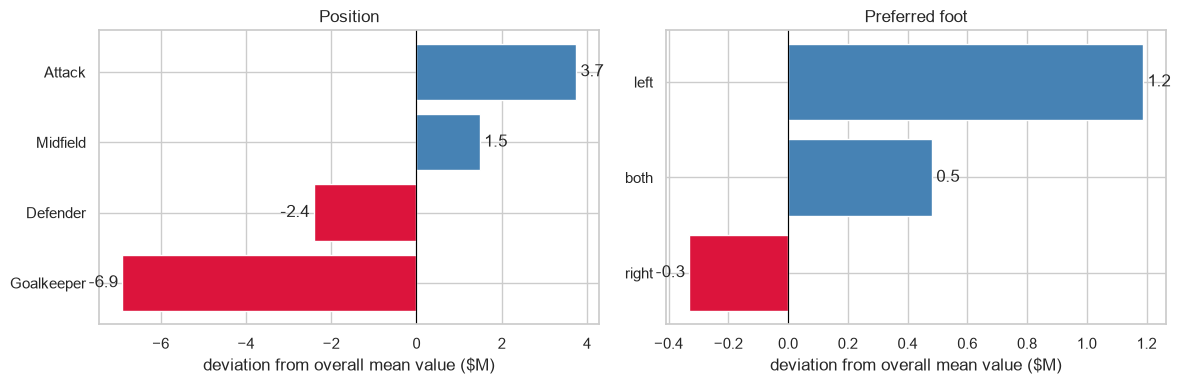

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_deviation(position_dev, "Position", ax=axes[0])
plot_deviation(foot_dev, "Preferred foot", ax=axes[1])
plt.tight_layout()
plt.show()